<div style="text-align: center;">

# Robotics and its Application (AI352) | Assignment 3

## Workspace Analysis for Different Coordinate Systems

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>

## Animate a Circular Trajectory
We command the end-effector along a circle of radius $r$ within $[R_\text{inner}, R_\text{outer}]$ and compute joint angles by **closed-form IK**:
$$\theta_2 = \arccos\left(\frac{x^2+y^2 - L_1^2 - L_2^2}{2 L_1 L_2}\right)$$
$$\theta_1 = \operatorname{atan2}(y,x) - \operatorname{atan2}(L_2\sin\theta_2, L_1 + L_2\cos\theta_2)$$
We then draw links $[0 \to p_1 \to p_2]$ frame-by-frame using `matplotlib.animation.FuncAnimation`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

from matplotlib import animation
from IPython.display import HTML

def ik_2r(x, y, L1, L2, elbow='down'):
    d = (x**2 + y**2 - L1**2 - L2**2) / (2*L1*L2)
    d = np.clip(d, -1.0, 1.0)  # numerical safety
    if elbow == 'down':
        t2 = np.arccos(d)
    else:
        t2 = -np.arccos(d)
    t1 = np.arctan2(y, x) - np.arctan2(L2*np.sin(t2), L1 + L2*np.cos(t2))
    return t1, t2

def animate_circle(L1=1.0, L2=1.0, r_ratio=0.6, T=6.0, fps=30, elbow='down'):
    R_out, R_in = L1+L2, abs(L1-L2)
    r = max(min(r_ratio*R_out, R_out*0.95), max(R_in*1.05, 1e-6))
    frames = int(T*fps)
    t = np.linspace(0, 2*np.pi, frames, endpoint=False)
    x = r*np.cos(t); y = r*np.sin(t)
    th1, th2 = ik_2r(x, y, L1, L2, elbow=elbow)

    fig = plt.figure(figsize=(6.5, 6.5))
    ax = plt.gca()
    ax.set_xlim(-(L1+L2)*1.1, (L1+L2)*1.1)
    ax.set_ylim(-(L1+L2)*1.1, (L1+L2)*1.1)
    ax.set_aspect('equal'); ax.grid(True)
    line, = ax.plot([], [], marker='o', lw=3)
    tip_path, = ax.plot([], [], lw=1)
    ax.add_patch(plt.Circle((0,0), L1+L2, fill=False, linestyle='--'))
    ax.add_patch(plt.Circle((0,0), abs(L1-L2), fill=False, linestyle='--'))
    ax.set_title('2R Arm Circular end-effector Trajectory')

    xs_path, ys_path = [], []

    def fk(theta1, theta2):
        x1 = L1*np.cos(theta1); y1 = L1*np.sin(theta1)
        x2 = x1 + L2*np.cos(theta1+theta2)
        y2 = y1 + L2*np.sin(theta1+theta2)
        return (0, x1, x2), (0, y1, y2)

    def init():
        line.set_data([], []); tip_path.set_data([], []); return line, tip_path

    def update(i):
        Xs, Ys = fk(th1[i], th2[i])
        xs_path.append(Xs[-1]); ys_path.append(Ys[-1])
        line.set_data(Xs, Ys)
        tip_path.set_data(xs_path, ys_path)
        return line, tip_path

    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, interval=1000/fps, blit=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())  # inline, no external encoders

# Run the animation (adjust r_ratio in [0,1] if desired)
animate_circle(L1=1.0, L2=1.0, r_ratio=0.7, T=5.0, fps=30, elbow='down')


<div style="text-align: center; max-width: 550px; margin: 0 auto;">

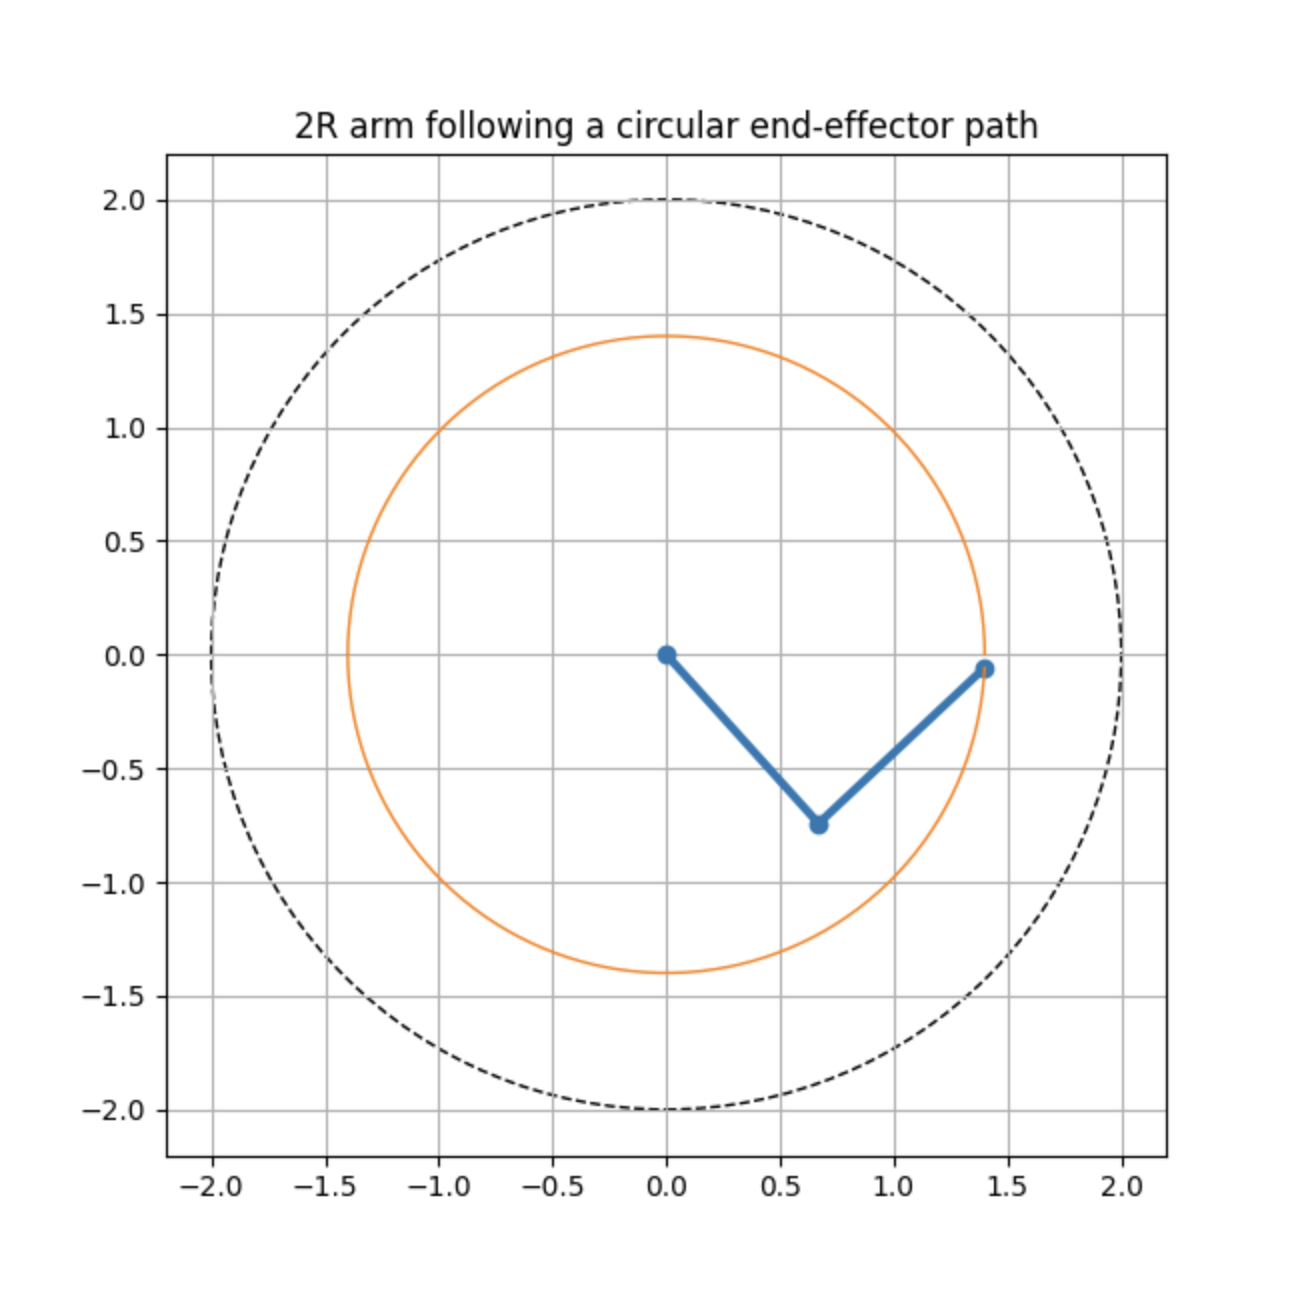

</div>

<div style="text-align: center;">

**Image 1:** 2R Circular trajectory

</div>


## Interactive GUI for nR planar

In [ ]:

try:
    import ipywidgets as widgets
    from ipywidgets import HBox, VBox, Layout
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError as e:
    print(f"ipywidgets is not available: {e}")
    print("Please install ipywidgets with: pip install ipywidgets")
    print("Then restart the kernel and try again.")
    WIDGETS_AVAILABLE = False


def fk_chain(joint_angles, link_lengths):
    """Return arrays X, Y of joint positions for a planar nR chain."""
    thetas = np.cumsum(joint_angles)
    xs = np.cumsum(link_lengths * np.cos(thetas))
    ys = np.cumsum(link_lengths * np.sin(thetas))
    X = np.concatenate([[0], xs])
    Y = np.concatenate([[0], ys])
    return X, Y


def sample_workspace_nR(link_lengths, samples=5000):
    """Sample workspace points for an nR robot using Monte Carlo method."""
    n = len(link_lengths)
    th = np.random.uniform(-np.pi, np.pi, size=(samples, n))
    thetas = np.cumsum(th, axis=1)
    x = np.sum(link_lengths * np.cos(thetas), axis=1)
    y = np.sum(link_lengths * np.sin(thetas), axis=1)
    return x, y


def parse_lengths(text, n):
    """Parse comma-separated link lengths from text input."""
    try:
        parts = [p.strip() for p in text.split(',') if p.strip() != '']
        vals = [float(p) for p in parts][:n]
        if len(vals) < n:
            vals += [1.0] * (n - len(vals))
        return np.array(vals)
    except ValueError:
        # Return default values if parsing fails
        return np.array([1.0] * n)


def make_nr_gui():
    """Create interactive GUI for nR robot arm visualization."""
    if not WIDGETS_AVAILABLE:
        print("Cannot create GUI: ipywidgets is not available.")
        print("Showing a static example instead...")

        # Show a static example
        L = np.array([1.0, 1.0, 0.8])
        angles = np.array([0.5, -0.3, 0.8])

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Plot workspace
        x_ws, y_ws = sample_workspace_nR(L, samples=3000)
        ax1.scatter(x_ws, y_ws, s=1, alpha=0.3, label='Workspace samples')
        ax1.set_aspect('equal')
        ax1.grid(True)
        ax1.set_title('3R Robot Workspace')
        ax1.legend()

        # Plot current configuration
        X, Y = fk_chain(angles, L)
        ax2.plot(X, Y, marker='o', lw=3, markersize=8, label='Robot arm')
        ax2.set_aspect('equal')
        ax2.grid(True)
        ax2.set_title(f'3R Robot Configuration\nAngles: {angles}')
        ax2.legend()

        plt.tight_layout()
        plt.show()
        return

    # Default config
    n_slider = widgets.IntSlider(
        value=3,
        min=2,
        max=6,
        step=1,
        description='Joints n:',
        continuous_update=False
    )

    lengths_text = widgets.Text(
        value='1,1,1',
        description='Links L:',
        layout=Layout(width='300px')
    )

    samples_slider = widgets.IntSlider(
        value=2000,
        min=500,
        max=20000,
        step=500,
        description='Workspace samples:',
        continuous_update=False
    )

    compute_ws = widgets.ToggleButton(
        value=True,
        description='Show workspace',
        tooltip='Toggle workspace sampling'
    )

    reset_btn = widgets.Button(description='Reset Angles')

    # Container for dynamic angle sliders
    angles_box = VBox([])
    output = widgets.Output()

    def rebuild_angle_sliders(n):
        """Create angle sliders for n joints."""
        sliders = []
        for i in range(n):
            slider = widgets.FloatSlider(
                value=0.0,
                min=-np.pi,
                max=np.pi,
                step=0.01,
                description=f'θ{i+1}',
                continuous_update=True,  # This enables real-time updates
                readout_format='.2f'
            )
            sliders.append(slider)
        angles_box.children = sliders

    def refresh_plot(*args):
        """Update the plot based on current slider values."""
        with output:
            clear_output(wait=True)
            try:
                n = n_slider.value
                L = parse_lengths(lengths_text.value, n)

                # Current angles from sliders
                if len(angles_box.children) != n:
                    rebuild_angle_sliders(n)

                angles = np.array([w.value for w in angles_box.children])

                # Create plot
                fig = plt.figure(figsize=(8, 8))
                ax = plt.gca()
                ax.set_aspect('equal')
                ax.grid(True)

                # Set plot limits
                rmax = np.sum(L) * 1.1
                ax.set_xlim(-rmax, rmax)
                ax.set_ylim(-rmax, rmax)

                # Optionally draw workspace samples
                if compute_ws.value:
                    xw, yw = sample_workspace_nR(L, samples=samples_slider.value)
                    ax.scatter(xw, yw, s=1, alpha=0.25, c='lightblue', label='Workspace samples')

                # Draw robot chain
                X, Y = fk_chain(angles, L)
                ax.plot(X, Y, marker='o', lw=3, markersize=8, color='red', label='Robot arm')

                # Add labels and formatting
                ax.legend(loc='upper right')
                ax.set_xlabel('X (m)')
                ax.set_ylabel('Y (m)')
                ax.set_title(f'{n}R Planar Robot Arm\nEnd-effector: ({X[-1]:.2f}, {Y[-1]:.2f})')
                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"Error in plotting: {e}")

    def on_reset_clicked(_):
        """Reset all angle sliders to zero."""
        for w in angles_box.children:
            w.value = 0.0
        refresh_plot()

    def on_n_changed(change):
        """Handle number of joints change."""
        rebuild_angle_sliders(change['new'])
        # Set up observers for new sliders
        for w in angles_box.children:
            w.observe(refresh_plot, names='value')
        refresh_plot()

    # Wire up event handlers
    n_slider.observe(on_n_changed, names='value')
    lengths_text.observe(lambda ch: refresh_plot(), names='value')
    samples_slider.observe(lambda ch: refresh_plot(), names='value')
    compute_ws.observe(lambda ch: refresh_plot(), names='value')
    reset_btn.on_click(on_reset_clicked)

    # Initial setup
    rebuild_angle_sliders(n_slider.value)
    for w in angles_box.children:
        w.observe(refresh_plot, names='value')

    # Layout the interface
    controls_left = VBox([n_slider, lengths_text, compute_ws, samples_slider, reset_btn])
    ui = HBox([controls_left, angles_box])

    display(ui, output)
    refresh_plot()


# Launch the GUI
make_nr_gui()


---

## Part B: Workspace Analysis of a 3R Planar Robot Arm

A **3R planar robot arm** has three revolute joints ($\theta_1, \theta_2, \theta_3$) and three rigid links ($L_1, L_2, L_3$). Unlike 2R, this robot has **kinematic redundancy** — multiple joint configurations can reach the same end-effector position.

**Forward Kinematics:**

$$x = L_1\cos(\theta_1) + L_2\cos(\theta_1+\theta_2) + L_3\cos(\theta_1+\theta_2+\theta_3)$$

$$y = L_1\sin(\theta_1) + L_2\sin(\theta_1+\theta_2) + L_3\sin(\theta_1+\theta_2+\theta_3)$$

**Workspace Boundaries:**
- **Outer radius:** $R_{\text{outer}} = L_1 + L_2 + L_3$ (all links aligned outward)
- **Inner radius:** $R_{\text{inner}} = |L_1 - L_2 - L_3|$ or $0$ if links can fold completely

In [ ]:
def compute_workspace_3r(L1, L2, L3, resolution=50):
    """Compute workspace for 3R planar robot using grid sampling."""
    theta_range = np.linspace(-np.pi, np.pi, resolution)
    
    x_points = []
    y_points = []
    
    for t1 in theta_range:
        for t2 in theta_range:
            for t3 in theta_range:
                x = L1*np.cos(t1) + L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3)
                y = L1*np.sin(t1) + L2*np.sin(t1+t2) + L3*np.sin(t1+t2+t3)
                x_points.append(x)
                y_points.append(y)
    
    return np.array(x_points), np.array(y_points)

def compute_workspace_3r_monte_carlo(L1, L2, L3, samples=10000):
    """Faster Monte Carlo sampling for 3R workspace."""
    t1 = np.random.uniform(-np.pi, np.pi, samples)
    t2 = np.random.uniform(-np.pi, np.pi, samples)
    t3 = np.random.uniform(-np.pi, np.pi, samples)
    
    x = L1*np.cos(t1) + L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3)
    y = L1*np.sin(t1) + L2*np.sin(t1+t2) + L3*np.sin(t1+t2+t3)
    return x, y

In [ ]:
L1, L2, L3 = 1.0, 0.8, 0.5

x_3r, y_3r = compute_workspace_3r_monte_carlo(L1, L2, L3, samples=15000)

fig, ax = plt.subplots(figsize=(8, 8))
distance = np.sqrt(x_3r**2 + y_3r**2)
scatter = ax.scatter(x_3r, y_3r, s=1, c=distance, cmap='viridis', alpha=0.5)

R_outer = L1 + L2 + L3
R_inner = abs(L1 - L2 - L3)
ax.add_patch(plt.Circle((0,0), R_outer, fill=False, linestyle='--', color='red', label=f'Outer: {R_outer}'))
if R_inner > 0.01:
    ax.add_patch(plt.Circle((0,0), R_inner, fill=False, linestyle='--', color='blue', label=f'Inner: {R_inner:.2f}'))

ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title(f'3R Robot Workspace: L1={L1}, L2={L2}, L3={L3}')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.colorbar(scatter, label='Reach Distance (m)')
plt.show()

> **3R Circular Trajectory Animation**

For animating, we need inverse kinematics. Since 3R is redundant, we fix $\theta_3$ (e.g., keep end-effector orientation constant) and solve for $\theta_1, \theta_2$ using the 2R IK approach on the "virtual" 2-link formed by combining the last two links.

In [ ]:
def ik_3r_fixed_orientation(x, y, L1, L2, L3, phi=0):
    """
    IK for 3R with fixed end-effector orientation phi.
    Wrist position: (xw, yw) = (x - L3*cos(phi), y - L3*sin(phi))
    Then solve 2R IK for wrist.
    """
    xw = x - L3 * np.cos(phi)
    yw = y - L3 * np.sin(phi)
    
    d = (xw**2 + yw**2 - L1**2 - L2**2) / (2*L1*L2)
    d = np.clip(d, -1.0, 1.0)
    
    t2 = np.arccos(d)
    t1 = np.arctan2(yw, xw) - np.arctan2(L2*np.sin(t2), L1 + L2*np.cos(t2))
    t3 = phi - t1 - t2
    
    return t1, t2, t3

def animate_3r_circle(L1=1.0, L2=0.8, L3=0.5, r_ratio=0.5, T=6.0, fps=30):
    R_out = L1 + L2 + L3
    r = r_ratio * R_out
    
    frames = int(T * fps)
    t = np.linspace(0, 2*np.pi, frames, endpoint=False)
    x_traj = r * np.cos(t)
    y_traj = r * np.sin(t)
    
    th1, th2, th3 = ik_3r_fixed_orientation(x_traj, y_traj, L1, L2, L3, phi=0)
    
    fig = plt.figure(figsize=(7, 7))
    ax = plt.gca()
    ax.set_xlim(-R_out*1.1, R_out*1.1)
    ax.set_ylim(-R_out*1.1, R_out*1.1)
    ax.set_aspect('equal')
    ax.grid(True)
    
    line, = ax.plot([], [], 'o-', lw=3, markersize=6)
    path, = ax.plot([], [], 'g-', lw=1, alpha=0.7)
    ax.add_patch(plt.Circle((0,0), R_out, fill=False, linestyle='--', alpha=0.5))
    ax.set_title('3R Robot - Circular Trajectory')
    
    xs_path, ys_path = [], []
    
    def fk_3r(t1, t2, t3):
        x1, y1 = L1*np.cos(t1), L1*np.sin(t1)
        x2 = x1 + L2*np.cos(t1+t2)
        y2 = y1 + L2*np.sin(t1+t2)
        x3 = x2 + L3*np.cos(t1+t2+t3)
        y3 = y2 + L3*np.sin(t1+t2+t3)
        return [0, x1, x2, x3], [0, y1, y2, y3]
    
    def init():
        line.set_data([], [])
        path.set_data([], [])
        return line, path
    
    def update(i):
        Xs, Ys = fk_3r(th1[i], th2[i], th3[i])
        xs_path.append(Xs[-1])
        ys_path.append(Ys[-1])
        line.set_data(Xs, Ys)
        path.set_data(xs_path, ys_path)
        return line, path
    
    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, 
                                   interval=1000/fps, blit=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_3r_circle(L1=1.0, L2=0.8, L3=0.5, r_ratio=0.5, T=5.0)

> **Comparison: 2R vs 3R Workspace**

| Feature | 2R Robot | 3R Robot |
|---------|----------|----------|
| Degrees of Freedom | 2 | 3 |
| Workspace Shape | Annular ring | Filled disk (if links allow) |
| Redundancy | None | Yes (infinite solutions for same point) |
| Dexterity | Limited | Higher flexibility |
| Inner hole | $\|L_1 - L_2\|$ | Can be zero if $L_1 \leq L_2 + L_3$ |

In [ ]:
# Visual comparison of 2R and 3R workspaces
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2R workspace
L1_2r, L2_2r = 1.5, 1.0
theta = np.linspace(-np.pi, np.pi, 80)
t1, t2 = np.meshgrid(theta, theta)
x_2r = L1_2r*np.cos(t1) + L2_2r*np.cos(t1+t2)
y_2r = L1_2r*np.sin(t1) + L2_2r*np.sin(t1+t2)

axes[0].scatter(x_2r.flatten(), y_2r.flatten(), s=1, alpha=0.4, c='blue')
axes[0].add_patch(plt.Circle((0,0), L1_2r+L2_2r, fill=False, color='red', linestyle='--'))
axes[0].add_patch(plt.Circle((0,0), abs(L1_2r-L2_2r), fill=False, color='green', linestyle='--'))
axes[0].set_title(f'2R Workspace: L1={L1_2r}, L2={L2_2r}')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
axes[0].axis('equal'); axes[0].grid(True, alpha=0.3)

# 3R workspace
L1_3r, L2_3r, L3_3r = 1.0, 0.8, 0.7
x_3r, y_3r = compute_workspace_3r_monte_carlo(L1_3r, L2_3r, L3_3r, samples=12000)

axes[1].scatter(x_3r, y_3r, s=1, alpha=0.4, c='purple')
axes[1].add_patch(plt.Circle((0,0), L1_3r+L2_3r+L3_3r, fill=False, color='red', linestyle='--'))
axes[1].set_title(f'3R Workspace: L1={L1_3r}, L2={L2_3r}, L3={L3_3r}')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].axis('equal'); axes[1].grid(True, alpha=0.3)

plt.suptitle('2R vs 3R Workspace Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Part C: Workspace Analysis of a PPP (Cartesian) Robot

A **PPP robot** consists of three prismatic joints aligned along the X, Y, and Z axes. This is also called a **Cartesian robot** because the workspace is a rectangular box.

**Forward Kinematics:**

$$x = L_1 + d_1$$
$$y = L_2 + d_2$$
$$z = L_3 + d_3$$

Where:
- $L_1, L_2, L_3$ are the initial link offsets
- $d_1, d_2, d_3$ are the joint displacements (each varies within its limits)

**Workspace Shape:** A rectangular parallelepiped (3D box) defined by the joint limits.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def ppp_forward_kinematics(d1, d2, d3, L1=0, L2=0, L3=0):
    x = L1 + d1
    y = L2 + d2
    z = L3 + d3
    return x, y, z

def compute_ppp_workspace(d1_range, d2_range, d3_range, L1=0, L2=0, L3=0, resolution=10):
    d1 = np.linspace(d1_range[0], d1_range[1], resolution)
    d2 = np.linspace(d2_range[0], d2_range[1], resolution)
    d3 = np.linspace(d3_range[0], d3_range[1], resolution)
    
    D1, D2, D3 = np.meshgrid(d1, d2, d3)
    X, Y, Z = ppp_forward_kinematics(D1, D2, D3, L1, L2, L3)
    
    return X.flatten(), Y.flatten(), Z.flatten()

In [ ]:
# PPP Workspace visualization
d1_range = (0, 2)
d2_range = (0, 1.5)
d3_range = (0, 1)

X, Y, Z = compute_ppp_workspace(d1_range, d2_range, d3_range, resolution=8)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X, Y, Z, s=5, alpha=0.3, c=Z, cmap='coolwarm')

# Draw workspace boundary box
x_min, x_max = d1_range
y_min, y_max = d2_range
z_min, z_max = d3_range

vertices = [
    [(x_min, y_min, z_min), (x_max, y_min, z_min), (x_max, y_max, z_min), (x_min, y_max, z_min)],
    [(x_min, y_min, z_max), (x_max, y_min, z_max), (x_max, y_max, z_max), (x_min, y_max, z_max)],
]

for v in vertices:
    ax.add_collection3d(Poly3DCollection([v], alpha=0.1, facecolor='cyan', edgecolor='black'))

ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('PPP Robot Workspace (Cartesian)')
plt.tight_layout()
plt.show()

> **PPP Robot Animation**

The animation shows the robot moving along a diagonal path within the workspace, demonstrating how each prismatic joint extends independently.

In [ ]:
def animate_ppp(d1_max=2.0, d2_max=1.5, d3_max=1.0, T=5.0, fps=25):
    frames = int(T * fps)
    t = np.linspace(0, 2*np.pi, frames)
    
    d1 = d1_max * (0.5 + 0.5*np.sin(t))
    d2 = d2_max * (0.5 + 0.5*np.sin(t + np.pi/3))
    d3 = d3_max * (0.5 + 0.5*np.sin(t + 2*np.pi/3))
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(0, d1_max*1.2)
    ax.set_ylim(0, d2_max*1.2)
    ax.set_zlim(0, d3_max*1.2)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('PPP Robot Animation')
    
    line, = ax.plot3D([], [], [], 'b-o', lw=3, markersize=8)
    path, = ax.plot3D([], [], [], 'r-', lw=1, alpha=0.5)
    
    xs_path, ys_path, zs_path = [], [], []
    
    def init():
        line.set_data_3d([], [], [])
        path.set_data_3d([], [], [])
        return line, path
    
    def update(i):
        X = [0, d1[i], d1[i], d1[i]]
        Y = [0, 0, d2[i], d2[i]]
        Z = [0, 0, 0, d3[i]]
        
        xs_path.append(d1[i]); ys_path.append(d2[i]); zs_path.append(d3[i])
        
        line.set_data_3d(X, Y, Z)
        path.set_data_3d(xs_path, ys_path, zs_path)
        return line, path
    
    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init,
                                   interval=1000/fps, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_ppp()

---

## Part D: Workspace Analysis of an RPP (Cylindrical) Robot

An **RPP robot** has one revolute joint (base rotation) followed by two prismatic joints. This creates a **cylindrical workspace**.

**Forward Kinematics:**

$$x = d_3 \cos(\theta_1)$$
$$y = d_3 \sin(\theta_1)$$
$$z = L_1 + d_2$$

Where:
- $\theta_1$ is the base rotation angle
- $d_2$ is the vertical extension
- $d_3$ is the radial extension
- $L_1$ is the base height offset

**Workspace Shape:** A hollow cylinder (annular in cross-section if $d_3$ has a minimum value > 0)

In [ ]:
def rpp_forward_kinematics(theta1, d2, d3, L1=0.5):
    x = d3 * np.cos(theta1)
    y = d3 * np.sin(theta1)
    z = L1 + d2
    return x, y, z

def compute_rpp_workspace(theta_range, d2_range, d3_range, L1=0.5, resolution=30):
    theta = np.linspace(theta_range[0], theta_range[1], resolution)
    d2 = np.linspace(d2_range[0], d2_range[1], resolution//2)
    d3 = np.linspace(d3_range[0], d3_range[1], resolution//2)
    
    T, D2, D3 = np.meshgrid(theta, d2, d3)
    X, Y, Z = rpp_forward_kinematics(T, D2, D3, L1)
    
    return X.flatten(), Y.flatten(), Z.flatten()

In [ ]:
# RPP Workspace visualization (cylindrical)
L1 = 0.5
theta_range = (-np.pi, np.pi)
d2_range = (0, 1.5)
d3_range = (0.3, 1.5)

X, Y, Z = compute_rpp_workspace(theta_range, d2_range, d3_range, L1, resolution=40)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X, Y, Z, s=2, alpha=0.3, c=Z, cmap='plasma')

ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('RPP Robot Workspace (Cylindrical)')
plt.colorbar(scatter, label='Height (m)', shrink=0.6)
plt.tight_layout()
plt.show()

> **RPP Robot Animation**

Animating a helical trajectory where the robot rotates around the base while extending radially and vertically.

In [ ]:
def animate_rpp(L1=0.5, d2_max=1.5, d3_max=1.5, T=6.0, fps=25):
    frames = int(T * fps)
    t = np.linspace(0, 4*np.pi, frames)
    
    theta1 = t
    d2 = d2_max * (0.5 + 0.4*np.sin(t/2))
    d3 = d3_max * (0.5 + 0.4*np.cos(t/3))
    
    x_ee, y_ee, z_ee = rpp_forward_kinematics(theta1, d2, d3, L1)
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(-d3_max*1.2, d3_max*1.2)
    ax.set_ylim(-d3_max*1.2, d3_max*1.2)
    ax.set_zlim(0, L1 + d2_max*1.2)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('RPP Robot Animation')
    
    line, = ax.plot3D([], [], [], 'b-o', lw=3, markersize=8)
    path, = ax.plot3D([], [], [], 'r-', lw=1, alpha=0.5)
    
    xs_path, ys_path, zs_path = [], [], []
    
    def init():
        line.set_data_3d([], [], [])
        path.set_data_3d([], [], [])
        return line, path
    
    def update(i):
        X = [0, 0, x_ee[i]]
        Y = [0, 0, y_ee[i]]
        Z = [0, L1 + d2[i], z_ee[i]]
        
        xs_path.append(x_ee[i]); ys_path.append(y_ee[i]); zs_path.append(z_ee[i])
        
        line.set_data_3d(X, Y, Z)
        path.set_data_3d(xs_path, ys_path, zs_path)
        return line, path
    
    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init,
                                   interval=1000/fps, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_rpp()

---

## Part E: Workspace Analysis of an RRP (Spherical) Robot

An **RRP robot** (also called a **spherical robot**) has two revolute joints followed by a prismatic joint. The workspace forms a **spherical shell**.

**Forward Kinematics:**

$$x = d_3 \sin(\theta_2) \cos(\theta_1)$$
$$y = d_3 \sin(\theta_2) \sin(\theta_1)$$
$$z = L_1 + d_3 \cos(\theta_2)$$

Where:
- $\theta_1$ is the azimuth angle (base rotation, 0 to $2\pi$)
- $\theta_2$ is the elevation angle (tilt from vertical)
- $d_3$ is the radial extension
- $L_1$ is the base height offset

**Workspace Shape:** A thick spherical shell between radii $d_{3,\min}$ and $d_{3,\max}$, potentially with limits on $\theta_2$.

In [ ]:
def rrp_forward_kinematics(theta1, theta2, d3, L1=0.5):
    x = d3 * np.sin(theta2) * np.cos(theta1)
    y = d3 * np.sin(theta2) * np.sin(theta1)
    z = L1 + d3 * np.cos(theta2)
    return x, y, z

def compute_rrp_workspace(theta1_range, theta2_range, d3_range, L1=0.5, resolution=30):
    theta1 = np.linspace(theta1_range[0], theta1_range[1], resolution)
    theta2 = np.linspace(theta2_range[0], theta2_range[1], resolution//2)
    d3 = np.linspace(d3_range[0], d3_range[1], resolution//3)
    
    T1, T2, D3 = np.meshgrid(theta1, theta2, d3)
    X, Y, Z = rrp_forward_kinematics(T1, T2, D3, L1)
    
    return X.flatten(), Y.flatten(), Z.flatten()

In [ ]:
# RRP Workspace visualization (spherical shell)
L1 = 0.5
theta1_range = (0, 2*np.pi)
theta2_range = (0.1, np.pi - 0.1)  # avoid singularities at poles
d3_range = (0.5, 1.5)

X, Y, Z = compute_rrp_workspace(theta1_range, theta2_range, d3_range, L1, resolution=40)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

distance = np.sqrt(X**2 + Y**2 + (Z-L1)**2)
scatter = ax.scatter(X, Y, Z, s=2, alpha=0.3, c=distance, cmap='viridis')

ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('RRP Robot Workspace (Spherical)')
plt.colorbar(scatter, label='Radial Distance (m)', shrink=0.6)
plt.tight_layout()
plt.show()

> **RRP Robot Animation**

The animation traces a spiral path on the spherical workspace, varying both rotation angles while the arm extends and retracts.

In [ ]:
def animate_rrp(L1=0.5, d3_min=0.5, d3_max=1.5, T=8.0, fps=25):
    frames = int(T * fps)
    t = np.linspace(0, 4*np.pi, frames)
    
    theta1 = t
    theta2 = np.pi/4 + (np.pi/3)*np.sin(t/2)
    d3 = (d3_min + d3_max)/2 + ((d3_max - d3_min)/3)*np.cos(t/1.5)
    
    x_ee, y_ee, z_ee = rrp_forward_kinematics(theta1, theta2, d3, L1)
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    max_reach = d3_max * 1.2
    ax.set_xlim(-max_reach, max_reach)
    ax.set_ylim(-max_reach, max_reach)
    ax.set_zlim(0, L1 + max_reach)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('RRP Robot Animation (Spherical)')
    
    line, = ax.plot3D([], [], [], 'b-o', lw=3, markersize=8)
    path, = ax.plot3D([], [], [], 'r-', lw=1, alpha=0.5)
    
    xs_path, ys_path, zs_path = [], [], []
    
    def init():
        line.set_data_3d([], [], [])
        path.set_data_3d([], [], [])
        return line, path
    
    def update(i):
        X = [0, 0, x_ee[i]]
        Y = [0, 0, y_ee[i]]
        Z = [0, L1, z_ee[i]]
        
        xs_path.append(x_ee[i]); ys_path.append(y_ee[i]); zs_path.append(z_ee[i])
        
        line.set_data_3d(X, Y, Z)
        path.set_data_3d(xs_path, ys_path, zs_path)
        return line, path
    
    ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init,
                                   interval=1000/fps, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_rrp()

---

## Summary: Workspace Comparison

| Robot Type | Joint Config | Workspace Shape | Key Characteristics |
|------------|--------------|-----------------|---------------------|
| **2R** | RR | Annular ring (2D) | Simple, no redundancy |
| **3R** | RRR | Full disk possible (2D) | Redundant, better dexterity |
| **PPP** | PPP | Rectangular box (3D) | Easiest to control, no singularities |
| **RPP** | RPP | Cylinder (3D) | Good for cylindrical tasks |
| **RRP** | RRP | Spherical shell (3D) | Large 3D reach |

**Key Takeaways:**
- **Prismatic joints** create linear/rectangular workspaces
- **Revolute joints** create curved/circular workspaces
- Adding more joints increases workspace coverage and **redundancy**
- Workspace analysis is crucial for **task planning** and **robot selection**